# 9. Scaling up: RWC-P, Fig. 4 and the failure analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hale-T2/CHORD/blob/main/notebooks/09_scaling_rwc_p.ipynb)

> **Paper ↔ code.** Section IV-B: 100 RWC-P tracks, average F1 0.4505 (template) vs 0.5566 (HMM), Fig. 4 (tracks sorted by HMM F1), Table II (tracks where template matching wins), failure analysis (vocals, drums, power chords, first-order assumption, tempo). Functions: `plots.plot_f1_curve`, `features.harmonic_part`, `hmm.estimate_transition_matrix`; the paper's numbers are in `chordlab.paper_results`.

**Data.** RWC-P is 4.1 GB. Choose one of the strategies from notebook 1 in the cell below; the default runs on the six Table II tracks plus two controls, fetched one by one.

In [1]:
# --- Setup: works locally (run from anywhere inside the repository) and on Google Colab ---
import os, sys, pathlib, subprocess

REPO = "Hale-T2/CHORD"   # <-- change this after forking

if "google.colab" in sys.modules:
    root = pathlib.Path("/content") / REPO.split("/")[1]
    if not root.exists():
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", str(root)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(root)], check=True)
else:
    root = pathlib.Path.cwd().resolve()
    while not (root / "chordlab").exists() and root != root.parent:
        root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import IPython.display as ipd

import chordlab
from chordlab import data, features, templates, hmm, evaluate, midi_chords, synth, plots

plt.rcParams["figure.figsize"] = (11, 3.5)
plt.rcParams["figure.dpi"] = 110
print(f"chordlab {chordlab.__version__} loaded from {root}")
print("data folder:", data.data_root())

chordlab 0.1.0 loaded from C:\Users\uture\Downloads\files\chord-recognition-book\chord-recognition-book
data folder: D:\rwc-data


In [2]:
# Optional (Colab only): keep downloads on Google Drive so they survive the session.
# from google.colab import drive
# drive.mount("/content/drive")
# data.set_data_root("/content/drive/MyDrive/chordlab-data")

In [3]:
from chordlab import paper_results

RUN_ALL = False            # True: all 100 tracks (needs data.download_rwc("P") or a Drive copy — several hours of CPU)
SUBSET = list(paper_results.TABLE_II.index) + ["RWC_P001", "RWC_P013", "RWC_P096"]

ann = data.ensure_annotations()
meta = data.load_metadata(ann)
track_list = data.track_ids("P", ann) if RUN_ALL else SUBSET

if RUN_ALL:
    data.ensure_rwc("P")
else:
    for rid in track_list:
        try:
            data.audio_path(rid)
        except FileNotFoundError:
            data.fetch_single_track(rid)          # pip install remotezip  (one ~40 MB member per track)
print(len(track_list), "tracks ready")

9 tracks ready


## 9.1 Run the pipeline

Same code as notebook 8, now against the **human** chord annotations (reduced with the paper's rule). Each track takes a few seconds; results are cached to `results/rwc_p_results.csv` so you can stop and resume.

In [4]:
hop_s = features.HOP_LENGTH / features.SR
cache = root / "results" / "rwc_p_results.csv"
done = pd.read_csv(cache, index_col=0) if cache.exists() else pd.DataFrame()
rows = done.to_dict("index")
for rid in track_list:
    if rid in rows:
        continue
    y, sr = features.load_audio(data.audio_path(rid))
    chroma, times = features.cqt_chroma(y, sr)
    ref_iv, ref_lab = data.load_chords(rid, ann)
    st_t, _ = templates.template_decode(chroma)
    st_h, _ = hmm.hmm_decode(chroma)
    mt = evaluate.evaluate_track(st_t, times, ref_iv, ref_lab, hop_s)
    mh = evaluate.evaluate_track(st_h, times, ref_iv, ref_lab, hop_s)
    rows[rid] = {"Template_P": mt["P"], "Template_R": mt["R"], "Template_F1": mt["F1"], "Template_majmin": mt["mir_eval_majmin"],
                 "HMM_P": mh["P"], "HMM_R": mh["R"], "HMM_F1": mh["F1"], "HMM_majmin": mh["mir_eval_majmin"],
                 "drums": meta.loc[rid, "DrumInformation"], "tempo": meta.loc[rid, "Tempo"]}
    pd.DataFrame(rows).T.to_csv(cache)
    print(f"{rid}  template F1 {mt['F1']:.3f}   HMM F1 {mh['F1']:.3f}")
res = pd.DataFrame(rows).T.astype({c: float for c in ["Template_P", "Template_R", "Template_F1", "Template_majmin", "HMM_P", "HMM_R", "HMM_F1", "HMM_majmin", "tempo"]})
res.loc[track_list].round(3)

RWC_P092  template F1 0.148   HMM F1 0.000


RWC_P015  template F1 0.307   HMM F1 0.126


RWC_P028  template F1 0.186   HMM F1 0.123


RWC_P091  template F1 0.330   HMM F1 0.402


RWC_P089  template F1 0.284   HMM F1 0.074


RWC_P031  template F1 0.079   HMM F1 0.000


RWC_P001  template F1 0.199   HMM F1 0.062


RWC_P013  template F1 0.492   HMM F1 0.296


RWC_P096  template F1 0.136   HMM F1 0.067


,Template_P,Template_R,Template_F1,Template_majmin,HMM_P,HMM_R,HMM_F1,HMM_majmin,drums,tempo
RWC_P092,0.133,0.168,0.148,0.172,0.000,0.000,0.000,0.011,Drum sequences,134.0
RWC_P015,0.301,0.313,0.307,0.312,0.124,0.129,0.126,0.135,Drum sequences,132.0
RWC_P028,0.171,0.203,0.186,0.206,0.114,0.135,0.123,0.139,Drum sequences,109.0
RWC_P091,0.327,0.333,0.330,0.365,0.398,0.405,0.402,0.452,Drum sequences,124.0
RWC_P089,0.278,0.291,0.284,0.292,0.072,0.076,0.074,0.081,Drum sequences,134.0
RWC_P031,0.079,0.079,0.079,0.078,0.000,0.000,0.000,0.000,Drum loops,129.0
RWC_P001,0.193,0.206,0.199,0.211,0.061,0.064,0.062,0.074,Drum sequences,135.0
RWC_P013,0.484,0.500,0.492,0.499,0.291,0.301,0.296,0.302,Drum sequences,103.0
RWC_P096,0.133,0.140,0.136,0.137,0.065,0.068,0.067,0.064,Drum loops,130.0


## 9.2 Fig. 4 and the averages

The paper's figure sorts tracks by HMM F1, draws the template F1 as a dashed line and marks the tracks where the template wins. With all 100 tracks you reproduce it directly; with the subset you get a miniature.

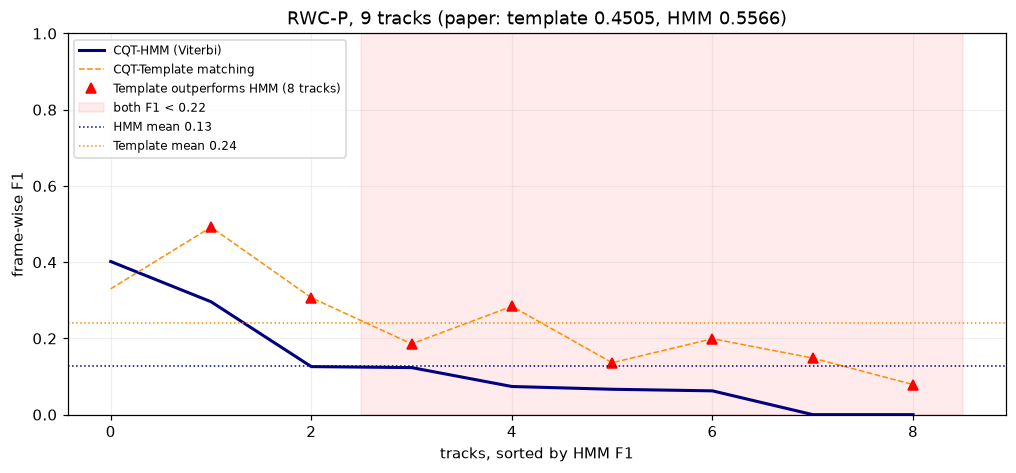

ours — template mean F1: 0.2402  HMM mean F1: 0.1278
tracks where template matching beats the HMM: 8 of 9 (paper: 14 of 100)


In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
plots.plot_f1_curve(res, ax=ax)
ax.set_title(f"RWC-P, {len(res)} tracks (paper: template {paper_results.RWC_P_AVERAGE_F1['CQT-Template']:.4f}, HMM {paper_results.RWC_P_AVERAGE_F1['CQT-HMM (Viterbi)']:.4f})")
plt.show()
print("ours — template mean F1:", res["Template_F1"].mean().round(4), " HMM mean F1:", res["HMM_F1"].mean().round(4))
print("tracks where template matching beats the HMM:", int((res["Template_F1"] > res["HMM_F1"]).sum()), "of", len(res), "(paper: 14 of 100)")

In [6]:
# Table II side by side
tab2 = paper_results.TABLE_II.join(res[["Template_F1", "HMM_F1"]], rsuffix="_ours").rename(columns={"Template_F1": "Template_F1_paper", "HMM_F1": "HMM_F1_paper"})
tab2.round(4)

,Template_F1_paper,HMM_F1_paper,Template_F1_ours,HMM_F1_ours
RWC_P092,0.2405,0.0954,0.1484,0.0000
RWC_P015,0.3711,0.2380,0.3067,0.1260
RWC_P028,0.3064,0.1902,0.1858,0.1235
RWC_P091,0.4763,0.3720,0.3300,0.4018
RWC_P089,0.3779,0.2781,0.2842,0.0738
RWC_P031,0.0730,0.0000,0.0790,0.0000


## 9.3 Failure analysis, with evidence

The paper names five culprits. Each can be *tested* rather than asserted.

**Drums.** `RWC_P031` is the paper's worst case (HMM F1 = 0.00). Look at its chromagram, then decode the *harmonic* component from harmonic/percussive source separation.

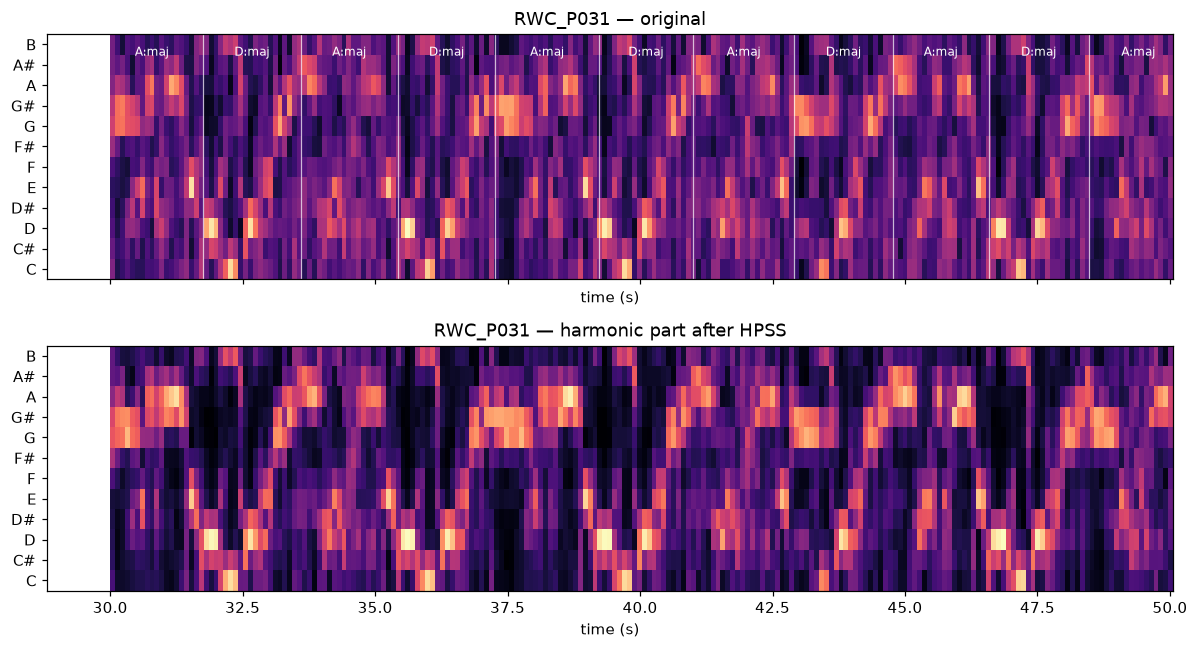

In [7]:
rid = "RWC_P031"
y, sr = features.load_audio(data.audio_path(rid), offset=30, duration=20)
ref_iv, ref_lab = data.load_chords(rid, ann)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, (sig, title) in zip(axes, [(y, "original"), (features.harmonic_part(y), "harmonic part after HPSS")]):
    c, t = features.cqt_chroma(sig, sr)
    plots.plot_chroma(c, t + 30, ax=ax, title=f"{rid} — {title}")
sel = (ref_iv[:, 1] > 30) & (ref_iv[:, 0] < 50)
plots.overlay_segments(axes[0], ref_iv[sel], evaluate.reduce_labels(np.array(ref_lab)[sel]))
plt.tight_layout(); plt.show()
ipd.Audio(y, rate=sr)

In [8]:
def f1_for(rid, transform=lambda y: y, **decode_kwargs):
    y, sr = features.load_audio(data.audio_path(rid))
    chroma, times = features.cqt_chroma(transform(y), sr)
    ref_iv, ref_lab = data.load_chords(rid, ann)
    st_t, _ = templates.template_decode(chroma)
    st_h, _ = hmm.hmm_decode(chroma, **decode_kwargs)
    return (evaluate.evaluate_track(st_t, times, ref_iv, ref_lab, hop_s, with_mir_eval=False)["F1"],
            evaluate.evaluate_track(st_h, times, ref_iv, ref_lab, hop_s, with_mir_eval=False)["F1"])

for rid in ["RWC_P031", "RWC_P092", "RWC_P001"]:
    base, hpss = f1_for(rid), f1_for(rid, features.harmonic_part)
    print(f"{rid}: template {base[0]:.3f} -> HPSS {hpss[0]:.3f}   |   HMM {base[1]:.3f} -> HPSS {hpss[1]:.3f}")

RWC_P031: template 0.079 -> HPSS 0.076   |   HMM 0.000 -> HPSS 0.000


RWC_P092: template 0.148 -> HPSS 0.126   |   HMM 0.000 -> HPSS 0.000


RWC_P001: template 0.199 -> HPSS 0.259   |   HMM 0.062 -> HPSS 0.108


**Drums, statistically.** `metadata.csv` says which tracks have *live drums*, *drum sequences* or none. If percussion is the culprit, F1 should differ between the groups (this needs `RUN_ALL = True` to be meaningful).

In [9]:
res.groupby("drums")[["Template_F1", "HMM_F1"]].agg(["mean", "count"]).round(3)

Template_F1       HMM_F1      
                      mean count   mean count
drums                                        
Drum loops           0.108     2  0.033     2
Drum sequences       0.278     7  0.155     7

**The first-order assumption and over-smoothing.** Notebook 6 showed that at τ = 1 the decoder needs tens of frames of evidence before it visits a chord that resembles its neighbour. Songs with fast changes between related chords suffer. Test the temperature on the Table II tracks:

In [10]:
for rid in paper_results.TABLE_II.index[:3]:
    print(rid, " ".join(f"τ={tau}: HMM F1 {f1_for(rid, temperature=tau)[1]:.3f}" for tau in (1.0, 0.3, 0.1)))

RWC_P092 τ=1.0: HMM F1 0.000 τ=0.3: HMM F1 0.000 τ=0.1: HMM F1 0.064


RWC_P015 τ=1.0: HMM F1 0.126 τ=0.3: HMM F1 0.170 τ=0.1: HMM F1 0.247


RWC_P028 τ=1.0: HMM F1 0.123 τ=0.3: HMM F1 0.129 τ=0.1: HMM F1 0.202


**A musical prior instead of a uniform one.** The key-invariant matrix estimated in notebook 6 came from *these very annotations*, so decoding a track with a matrix that saw its own labels would be cheating. Estimate the matrix from all *other* tracks (leave-one-out) and compare.

In [11]:
grid = 0.1
seqs = {}
for pid in data.track_ids("P", ann):
    iv, lab = data.load_chords(pid, ann)
    t = np.arange(0.0, iv[-1, 1], grid) + grid / 2
    seqs[pid] = evaluate.labels_to_frames(iv, lab, t)

for rid in track_list[:4]:
    A_loo = hmm.estimate_transition_matrix([s for p, s in seqs.items() if p != rid])
    # the 100 ms grid is coarser than our 93 ms hop; re-scale the self-transition mass to keep the same expected chord duration
    uniform, learned = f1_for(rid)[1], f1_for(rid, A=A_loo)[1]
    print(f"{rid}: HMM F1 uniform A {uniform:.3f}   learned key-invariant A (leave-one-out) {learned:.3f}")

RWC_P092: HMM F1 uniform A 0.000   learned key-invariant A (leave-one-out) 0.000


RWC_P015: HMM F1 uniform A 0.126   learned key-invariant A (leave-one-out) 0.155


RWC_P028: HMM F1 uniform A 0.123   learned key-invariant A (leave-one-out) 0.255


RWC_P091: HMM F1 uniform A 0.402   learned key-invariant A (leave-one-out) 0.402


**Tempo.** The paper attributes `RWC_P096` to non-linear tempo changes misaligning chord boundaries. That is a hypothesis about the *annotation*, not the decoder: check it by plotting the beat period over time from the beat annotation.

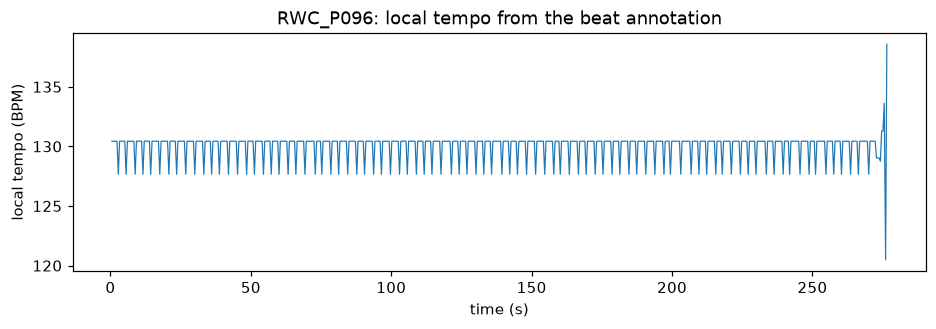

In [12]:
b, _ = data.load_beats("RWC_P096", ann)
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(b[1:], 60 / np.diff(b), lw=0.8)
ax.set(xlabel="time (s)", ylabel="local tempo (BPM)", title="RWC_P096: local tempo from the beat annotation")
plt.show()

## 9.4 Runtime

The paper's future work mentions the cost of Viterbi. Measure it: the recurrence is O(T·S²) — with S = 24 that is small, and in NumPy the whole track decodes in well under a second. The CQT dominates.

In [13]:
import time
y, sr = features.load_audio(data.audio_path(track_list[0]))
t0 = time.perf_counter(); chroma, times = features.cqt_chroma(y, sr); t_cqt = time.perf_counter() - t0
t0 = time.perf_counter(); templates.template_decode(chroma); t_tmpl = time.perf_counter() - t0
t0 = time.perf_counter(); hmm.hmm_decode(chroma); t_hmm = time.perf_counter() - t0
print(f"{len(y) / sr:.0f} s of audio: CQT + chroma {t_cqt:.2f} s, template decode {t_tmpl * 1000:.1f} ms, HMM decode {t_hmm * 1000:.1f} ms")

218 s of audio: CQT + chroma 0.15 s, template decode 0.6 ms, HMM decode 23.7 ms


## 9.5 Is the difference real?

With 100 paired measurements you can test whether the HMM's advantage is statistically distinguishable from noise — something the paper leaves to the reader.

In [14]:
from scipy.stats import wilcoxon, ttest_rel
if len(res) >= 10:
    print("paired t-test  :", ttest_rel(res["HMM_F1"], res["Template_F1"]))
    print("Wilcoxon signed:", wilcoxon(res["HMM_F1"], res["Template_F1"]))
else:
    print(f"only {len(res)} tracks — set RUN_ALL = True for a meaningful test")

only 9 tracks — set RUN_ALL = True for a meaningful test


## Exercises

1. Add a 25th `N` state (flat template, see notebook 6) and re-run the subset. Does `RWC_P031` still score 0?
2. The paper's Table II track `RWC_P015` had the lowest MIDI-vs-human agreement in notebook 7 as well. Listen to it. What is going on harmonically?
3. Beat-synchronous decoding: average the chroma between annotated beats (`librosa.util.sync`) before decoding, so that one "frame" is one beat. Recompute Fig. 4. Which of the paper's five failure causes does this address?
4. Write a short paragraph, in the style of the paper's §IV-B, reporting *your* numbers and *your* reading of them. Where do you agree with the paper and where does your evidence point elsewhere?